# 1. Problem Definition

The goal of this End-to-End project is to 
1. Predict **customer churn risk** on an e-commerce platform.  
2. Combine **sentiment analysis** with **behavioral data** to proactively identify high-risk customers at an early stage.  
3. Enable the development of personalized **retention strategies** through an **End-to-End project** to maximize customer lifetime value.  

This notebook focuses on the first part: **customer churn risk prediction**.


In [1]:
# !pip install -r ../requirements.txt

# 2. Data Collection

https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

In [2]:
import pandas as pd

base_path = "data/"  

orders = pd.read_csv(base_path + "olist_orders.csv")
items = pd.read_csv(base_path + "olist_order_items.csv")
customers = pd.read_csv(base_path + "olist_customers.csv")

In [3]:
# print("orders:", orders.shape)
# print("items:", items.shape)
# print("customers:", customers.shape)

# orders.head()

In [4]:
# items.head()

In [5]:
# customers.head()

# 3. EDA Reports

**Orders**  
- Convert order-related columns to datetime format.  
- Fill missing values in `order_delivered_customer_date` using the mean delivery time.  

**Items**  
- Verified product-level information and ensured consistency across orders.  

**Customers**  
- Checked customer distribution and duplicates. 

In [6]:
# import sys
# !{sys.executable} -m pip install ydata-profiling

In [7]:
# from ydata_profiling import ProfileReport

# dfs = {
#     "orders": orders,
#     "items": items,
#     "customers": customers
# }

# for name, df in dfs.items():
#     print(f"Generating report for: {name}")
#     profile = ProfileReport(df, title=f"{name.capitalize()} EDA Report", explorative=True)
#     profile.to_file(f"{name}_eda_report.html")


In [8]:
# print("=== ORDERS ===")
# print(orders.shape)
# print(orders.dtypes)
# print(orders.isnull().sum())
# print(orders.nunique())
# print(orders.describe())
# print(orders.describe(include='object'))

# print(items.dtypes)
# print(reviews.dtypes)

# 4. 5. Data Preprocessing & Feature Engineering + EDA

- Converted dates to **datetime** format  
- Created features based on **order and delivery information**
- Aggregated customer-level metrics (e.g. total number of orders, average order value, average delivery delay, etc.)  
- Defined the **churn label**: if more than 90 days have passed since the last purchase → `churned = 1`

Finally, created a customer-level feature table named **`features`**.


In [9]:
# Convert columns to datetime format
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])

In [10]:
orders = orders.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id", how="left"
)

customer_orders = orders.groupby("customer_unique_id").agg(
    total_orders=("order_id", "nunique"),
    last_order_date=("order_purchase_timestamp", "max")
).reset_index()


customer_orders.head()

,customer_unique_id,total_orders,last_order_date
0,0000366f3b9a7992bf8c76cfdf3221e2,1,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,1,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,1,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,1,2017-11-14 19:45:42


In [11]:
customer_orders["total_orders"].value_counts().sort_index()

total_orders
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

In [12]:
reorder_rate = (customer_orders["total_orders"] > 1).mean()
print(f"Reorder rate (>=2 orders): {reorder_rate:.2%}")

Reorder rate (>=2 orders): 3.12%


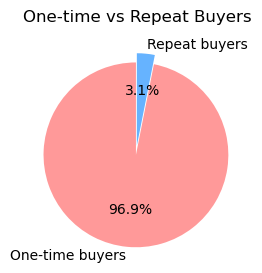

In [13]:
import matplotlib.pyplot as plt

labels = ["One-time buyers", "Repeat buyers"]
sizes = [
    (customer_orders["total_orders"] == 1).sum(),
    (customer_orders["total_orders"] > 1).sum()
]

colors = ['#ff9999', '#66b3ff']
explode = (0.1, 0)  

plt.figure(figsize=(3,3))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
        colors=colors, explode=explode)
plt.title("One-time vs Repeat Buyers")
plt.show()


### 1) One-time vs Repeat Buyers

The vast majority of customers (**~96.9%**) are one-time buyers,  
while only around **3.1%** return for repeat purchases.


In [14]:
customer_orders["last_order_date"].min(), customer_orders["last_order_date"].max()


(Timestamp('2016-09-04 21:15:19'), Timestamp('2018-10-17 17:30:18'))

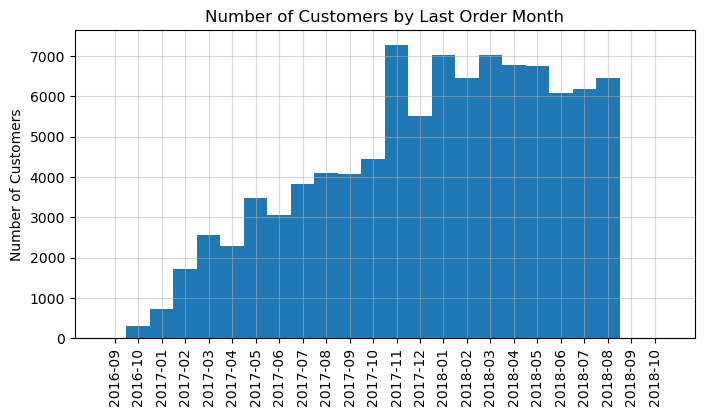

In [15]:
monthly_counts = customer_orders.groupby(
    customer_orders["last_order_date"].dt.to_period("M")
).size()

plt.figure(figsize=(8,4))
plt.bar(monthly_counts.index.astype(str), monthly_counts.values, width=1.0)
plt.xticks(rotation=90)
plt.title("Number of Customers by Last Order Month")
plt.ylabel("Number of Customers")
plt.grid(True, which="both", axis="both", linestyle="-", alpha=0.5)
plt.show()


### 2) Number of Customers by Last Order Month

Customer activity spans from **September 2016 to October 2018**.  
The number of customers increased steadily through 2017,  
peaked around late 2017 to early 2018, and then stabilized at a high level.


In [16]:
customer_orders.head()

,customer_unique_id,total_orders,last_order_date
0,0000366f3b9a7992bf8c76cfdf3221e2,1,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,1,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,1,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,1,2017-11-14 19:45:42


In [17]:
# Delivery delay = actual delivery date - estimated delivery date
orders["delivery_delay_days"] = (orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]).dt.days

# avg_delivery_delay per customer
avg_delay = orders.groupby("customer_unique_id").agg(
    avg_delivery_delay=("delivery_delay_days", "mean")
).reset_index()

avg_delay.head()

,customer_unique_id,avg_delivery_delay
0,0000366f3b9a7992bf8c76cfdf3221e2,-5.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,-5.0
2,0000f46a3911fa3c0805444483337064,-2.0
3,0000f6ccb0745a6a4b88665a16c9f078,-12.0
4,0004aac84e0df4da2b147fca70cf8255,-8.0


In [18]:
# Filter customers with a positive average delivery delay (received later than expected).
delayed_customers = avg_delay[avg_delay["avg_delivery_delay"] > 0]

delayed_customers_sorted = delayed_customers.sort_values(by="avg_delivery_delay", ascending=False)

delayed_customers_sorted.head()


,customer_unique_id,avg_delivery_delay
88354,eb21169c3153a2b507fc7e76d561ff14,188.0
27906,4a2519b6991378f6f2ce5ed22d308f03,181.0
28857,4cb8ad9a4554099db7d70c13d0dae906,175.0
45413,78d26ae26b5bb9cb398edc7384d3c15f,167.0
22664,3c2564d42f7ddd8b7576f0dd9cb1b4c5,166.0


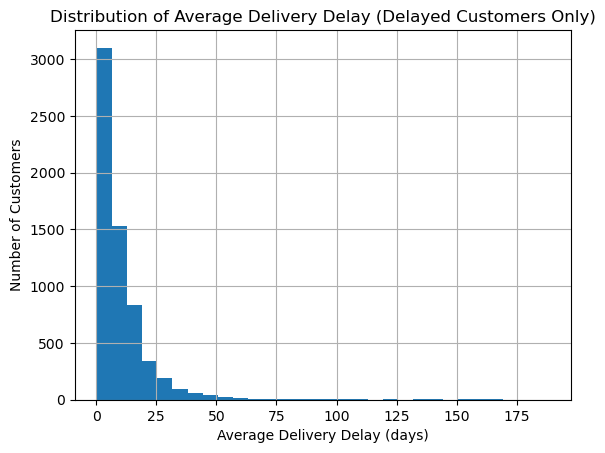

In [19]:
delayed_customers["avg_delivery_delay"].hist(bins=30)
plt.xlabel("Average Delivery Delay (days)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Average Delivery Delay (Delayed Customers Only)")
plt.show()


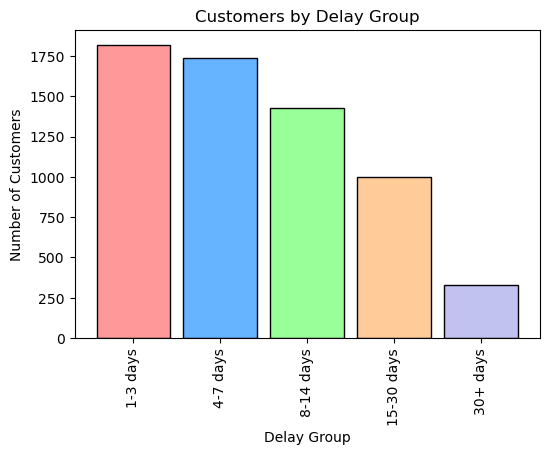

In [20]:
delayed_customers = delayed_customers.copy()

bins = [0, 3, 7, 14, 30, delayed_customers["avg_delivery_delay"].max()]
labels = ["1-3 days", "4-7 days", "8-14 days", "15-30 days", "30+ days"]

delayed_customers["delay_group"] = pd.cut(
    delayed_customers["avg_delivery_delay"],
    bins=bins, labels=labels, right=True
)

delayed_customers["delay_group"].value_counts().sort_index().plot(
    kind="bar", width=0.85, figsize=(6,4), color=["#ff9999","#66b3ff","#99ff99","#ffcc99","#c2c2f0"], edgecolor="black"
)
plt.title("Customers by Delay Group")
plt.ylabel("Number of Customers")
plt.xlabel("Delay Group")
plt.show()



### 3) Delivery Delay Distribution

Most delivery delays were relatively short.  
- A large majority of delayed customers experienced delays of **less than 1 week**.  
- The most common groups were **1–3 days** and **4–7 days**, each affecting ~1,700–1,800 customers.  
- Fewer customers faced longer delays, with only a small minority experiencing **30+ days** of delay.


In [21]:
# Delivery Delay Grouping: Early vs Delayed
avg_delay["delay_group"] = avg_delay["avg_delivery_delay"].apply(
    lambda x: "Early" if x < 0 else "Delayed"
)

group_summary = avg_delay.groupby("delay_group").agg(
    avg_delay_days=("avg_delivery_delay", "mean"),
    customer_count=("customer_unique_id", "count")
).reset_index()

print(group_summary)


  delay_group  avg_delay_days  customer_count
0     Delayed        8.862790           10285
1       Early      -13.670427           85811


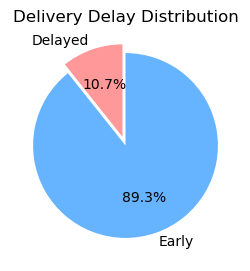

In [22]:
import matplotlib.pyplot as plt

# Pie chart data
labels = group_summary['delay_group']
sizes = group_summary['customer_count']

colors = ['#ff9999', '#66b3ff']
explode = (0.1, 0)  # Highlight the first group (Delayed)

# Draw pie chart
plt.figure(figsize=(3,3))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
        colors=colors, explode=explode)
plt.title("Delivery Delay Distribution")
plt.show()


### 4) Delivery Delay Distribution

The majority of customers (**~89%**) received their orders earlier than expected,  
while around **11%** experienced delivery delays.


In [23]:
## Create churn label

# Set reference date (e.g., based on the most recent order date)
reference_date = orders["order_purchase_timestamp"].max()

# Calculate how many days have passed since each customer's last purchase
customer_orders["days_since_last_order"] = (reference_date - customer_orders["last_order_date"]).dt.days

# Define churn label (e.g., churn if more than 90 days)
customer_orders["churned"] = customer_orders["days_since_last_order"] > 90
customer_orders["churned"] = customer_orders["churned"].astype(int)


In [24]:
# # churn 분포 확인
# customer_orders["churned"].value_counts()

# 비율로 확인
customer_orders["churned"].value_counts(normalize=True)


churned
1    0.899434
0    0.100566
Name: proportion, dtype: float64

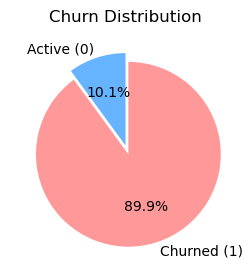

In [25]:
import matplotlib.pyplot as plt

labels = ["Active (0)", "Churned (1)"]
sizes = customer_orders["churned"].value_counts().sort_index()

colors = ['#66b3ff', '#ff9999']
explode = (0, 0.1)  # Highlight the churned group

plt.figure(figsize=(3,3))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
        colors=colors, explode=explode)
plt.title("Churn Distribution")
plt.show()


### 5) Churn Distribution

The majority of customers (~90%) are classified as churned,  
while only about 10% remain active.

In [26]:
# Calculate total purchase amount and number of items per order
order_prices = items.groupby("order_id").agg(
    order_value=("price", "sum"),
    num_items=("product_id", "count"),
    unique_products=("product_id", "nunique")
).reset_index()

# Merge order value/item information into order data
orders = orders.merge(order_prices, on="order_id", how="left")

In [27]:
# Calculate average order value, average number of items, and product diversity per customer
order_agg = orders.groupby("customer_unique_id").agg(
    avg_order_value=("order_value", "mean"),
    avg_num_items=("num_items", "mean"),
    avg_unique_products=("unique_products", "mean")
).reset_index()

In [28]:
# Calculate average actual delivery days per customer (delivery date - order date)
orders["actual_delivery_days"] = (orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]).dt.days

delivery_agg = orders.groupby("customer_unique_id").agg(
    avg_actual_delivery_days=("actual_delivery_days", "mean")
).reset_index()


In [29]:
# Combine all customer-level features and labels
# Create the final feature table for churn prediction
features = customer_orders.merge(avg_delay, on="customer_unique_id", how="left")
features = features.merge(order_agg, on="customer_unique_id", how="left")
features = features.merge(delivery_agg, on="customer_unique_id", how="left")

features.head()


,customer_unique_id,total_orders,last_order_date,days_since_last_order,churned,avg_delivery_delay,delay_group,avg_order_value,avg_num_items,avg_unique_products,avg_actual_delivery_days
0,0000366f3b9a7992bf8c76cfdf3221e2,1,2018-05-10 10:56:27,160,1,-5.0,Early,129.90,1.0,1.0,6.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,2018-05-07 11:11:27,163,1,-5.0,Early,18.90,1.0,1.0,3.0
2,0000f46a3911fa3c0805444483337064,1,2017-03-10 21:05:03,585,1,-2.0,Early,69.00,1.0,1.0,25.0
3,0000f6ccb0745a6a4b88665a16c9f078,1,2017-10-12 20:29:41,369,1,-12.0,Early,25.99,1.0,1.0,20.0
4,0004aac84e0df4da2b147fca70cf8255,1,2017-11-14 19:45:42,336,1,-8.0,Early,180.00,1.0,1.0,13.0


In [30]:
X = features.drop(columns=["customer_unique_id", "last_order_date", "days_since_last_order", "delay_group", "churned"])
y = features["churned"]

# Fill missing values with column means
X = X.fillna(X.mean())

X.head()

,total_orders,avg_delivery_delay,avg_order_value,avg_num_items,avg_unique_products,avg_actual_delivery_days
0,1,-5.0,129.90,1.0,1.0,6.0
1,1,-5.0,18.90,1.0,1.0,3.0
2,1,-2.0,69.00,1.0,1.0,25.0
3,1,-12.0,25.99,1.0,1.0,20.0
4,1,-8.0,180.00,1.0,1.0,13.0


# 6. Modeling

Three models were applied to compare churn prediction performance:

1. XGBoost  
2. Logistic Regression  
3. Random Forest  

**Evaluation Metrics**  
- **Accuracy**: Proportion of correct predictions among all predictions.
- **Precision**: Of all predicted positives, how many are truly positive? 
- **Recall**: Of all actual positives, how many were predicted positive? 
- **AUC**: Measures the model's ability to distinguish between classes across all possible thresholds (0.5 = random, 1 = perfect)
- **PR AUC (Average Precision, AP)**: Summarizes the trade-off between precision and recall across thresholds. Especially useful for imbalanced datasets.  


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### XGBoost

In [32]:
# %pip install xgboost


In [33]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

model = XGBClassifier(eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1] 

print("XGBoost")
print("AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("PR AUC (AP):", round(average_precision_score(y_test, y_proba), 4))
print(classification_report(y_test, y_pred))



XGBoost
AUC: 0.7969
PR AUC (AP): 0.9671
              precision    recall  f1-score   support

           0       0.71      0.23      0.35      1933
           1       0.92      0.99      0.95     17287

    accuracy                           0.91     19220
   macro avg       0.82      0.61      0.65     19220
weighted avg       0.90      0.91      0.89     19220



### Logistic Regression

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

y_pred_logreg = logreg.predict(X_test)
y_proba_logreg = logreg.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print("AUC:", round(roc_auc_score(y_test, y_proba_logreg),4))
print("PR AUC (AP):", round(average_precision_score(y_test, y_proba_logreg), 4))
print(classification_report(y_test, y_pred_logreg))



Logistic Regression
AUC: 0.7637
PR AUC (AP): 0.958
              precision    recall  f1-score   support

           0       0.96      0.08      0.15      1933
           1       0.91      1.00      0.95     17287

    accuracy                           0.91     19220
   macro avg       0.94      0.54      0.55     19220
weighted avg       0.91      0.91      0.87     19220



### Random Forest

In [35]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest")
print("AUC:", round(roc_auc_score(y_test, y_proba_rf),4))
print("PR AUC (AP):", round(average_precision_score(y_test, y_proba_rf), 4))

print(classification_report(y_test, y_pred_rf))



Random Forest
AUC: 0.7393
PR AUC (AP): 0.951
              precision    recall  f1-score   support

           0       0.43      0.29      0.35      1933
           1       0.92      0.96      0.94     17287

    accuracy                           0.89     19220
   macro avg       0.68      0.62      0.64     19220
weighted avg       0.87      0.89      0.88     19220



# 7. Evaluation & Conclusion

We evaluated three models: **XGBoost**, **Logistic Regression**, and **Random Forest**.

- **XGBoost**  
  - AUC: **0.80** (best overall)  
  - High recall for churn (label=1, recall=0.99, f1=0.95), meaning almost all churned customers were detected.

- **Logistic Regression**  
  - AUC: **0.76**  
  - High precision but extremely low recall for the non-churn class (label = 0, recall = 0.08).  

- **Random Forest**  
  - AUC: **0.74**  
  - Reasonable performance but underperformed compared to XGBoost.  

---

**Key Insight:**  
All models performed well in detecting churn customers but consistently failed to identify **non-churn customers (loyal/repeat buyers)**.
This is directly caused by the **severe class imbalance**.
- ~90% churn vs 10% non-churn
- only ~3% repeat buyers

| <img src="images/buyers.png" alt="One-time vs Repeat Buyers" width="150"> | <img src="images/churn.png" alt="Churn Distribution" width="150"> |
|:----------------------------------------------------------------------------:|:--------------------------------------------------------------------:|
| One-time vs Repeat Buyers                                                    | Churn Distribution                                                   |
---

| XGBoost | Logistic Regression | Random Forest |
|:-------:|:-------------------:|:-------------:|
| <img src="images/xgboost.png" width="250"/> | <img src="images/logistic.png" width="250"/> | <img src="images/randomforest.png" width="250"/> |



**Conclusion:**  
- Among the tested models, **XGBoost achieved the best overall performance (AUC=0.80)**, outperforming Logistic Regression and Random Forest.
- However, due to **extreme class imbalance**, all models predicted most customers as churn = 1, leading to very poor performance for churn=0 (repeat buyers).

To further explore whether the performance for **churn = 0** could be improved, two additional experiments were conducted: 

**(A)** applying various **class imbalance-handling techniques** (e.g., Class Weighting, SMOTE, SMOTETomek, Threshold Tuning) \
**(B)** **adjusting the churn window** definition (from 90 days -> 150 days) to create a more balanced dataset.
 


<hr style="height:3px; border:none; background-color:black;">

---

# (Extended) A. Handling Class Imbalance

The dataset is **heavily imbalanced** (~90% churn vs 10% non-churn, with only ~3% repeat buyers).  
This imbalance caused models to predict almost all customers as churn=1, leading to very poor performance for churn=0.  

In this section, we experiment with several techniques to address class imbalance, including **Class Weighting**, **SMOTE**, **SMOTETomek**, and **Threshold Tuning**.  
While these methods can partially mitigate the issue, the improvements for churn=0 were limited, reinforcing the need to reframe the task toward **probability prediction** in future work.


### 0. Imports, Helpers, and Baseline Models 

In [36]:
# Imports & Helpers
import numpy as np
import pandas as pd
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, average_precision_score,
    precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold

# Optional: if you used categorical/num features earlier
# num_cols, cat_cols should be defined; otherwise keep it simple with passthrough
preprocess = 'passthrough'  # or your ColumnTransformer

def pr_auc(y_true, y_proba):
    return average_precision_score(y_true, y_proba)

def eval_binary(y_true, y_proba, threshold=0.5, name='model', focus_label=0):
    """
    focus_label: 0이면 non-churn 중심, 1이면 churn 중심을 추가로 보여주기 위함
    """
    y_pred = (y_proba >= threshold).astype(int)
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    auc = roc_auc_score(y_true, y_proba)
    ap = pr_auc(y_true, y_proba)

    row = {
        'model': name,
        'AUC': round(auc, 4),
        'PR AUC': round(ap, 4),
        'Precision(0)': round(report['0']['precision'], 4),
        'Recall(0)': round(report['0']['recall'], 4),
        'F1(0)': round(report['0']['f1-score'], 4),
        'Precision(1)': round(report['1']['precision'], 4),
        'Recall(1)': round(report['1']['recall'], 4),
        'F1(1)': round(report['1']['f1-score'], 4),
    }
    return row, y_pred

def best_threshold_for_class(y_true, y_proba, target_label=0, optimize='f1'):
    """
    target_label=0에 집중: non-churn의 f1 또는 recall 최대화하는 threshold 탐색
    """
    # PR curve는 positive=1 기준이므로, label=0을 타겟으로 보려면 1-확률로 변환
    if target_label == 0:
        pos_scores = 1 - y_proba
        pos_true = (y_true == 0).astype(int)
    else:
        pos_scores = y_proba
        pos_true = y_true

    precisions, recalls, thresholds = precision_recall_curve(pos_true, pos_scores)
    thresholds = np.append(thresholds, 1.0)  # 길이 맞추기용

    if optimize == 'f1':
        f1s = (2 * precisions * recalls) / (precisions + recalls + 1e-12)
        idx = np.nanargmax(f1s)
        return 1 - thresholds[idx] if target_label == 0 else thresholds[idx], {
            'precision': float(precisions[idx]),
            'recall': float(recalls[idx]),
            'f1': float(f1s[idx])
        }
    elif optimize == 'recall':
        idx = np.nanargmax(recalls)
        return 1 - thresholds[idx] if target_label == 0 else thresholds[idx], {
            'precision': float(precisions[idx]),
            'recall': float(recalls[idx]),
        }
    else:
        raise ValueError("optimize must be 'f1' or 'recall'")


In [37]:
# Baseline models (no Pipeline, direct training)
results = []

# XGBoost (baseline)
xgb_base = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_base.fit(X_train, y_train)

y_pred_xgb = xgb_base.predict(X_test)
proba_xgb_base = xgb_base.predict_proba(X_test)[:, 1]

row, _ = eval_binary(y_test, proba_xgb_base, threshold=0.5, name='XGB (baseline)')
results.append(row)

# Logistic Regression (baseline)
log_base = LogisticRegression(max_iter=1000, random_state=42)
log_base.fit(X_train, y_train)

y_pred_logreg = log_base.predict(X_test)
proba_log_base = log_base.predict_proba(X_test)[:, 1]

row, _ = eval_binary(y_test, proba_log_base, threshold=0.5, name='LogReg (baseline)')
results.append(row)

# Random Forest (baseline)
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_base.fit(X_train, y_train)

y_pred_rf = rf_base.predict(X_test)
proba_rf_base = rf_base.predict_proba(X_test)[:, 1]

row, _ = eval_binary(y_test, proba_rf_base, threshold=0.5, name='RF (baseline)')
results.append(row)

pd.DataFrame(results)


,model,AUC,PR AUC,Precision(0),Recall(0),F1(0),Precision(1),Recall(1),F1(1)
0,XGB (baseline),0.7969,0.9671,0.7102,0.2333,0.3512,0.9203,0.9894,0.9536
1,LogReg (baseline),0.7637,0.9580,0.9641,0.0833,0.1533,0.9070,0.9997,0.9511
2,RF (baseline),0.7393,0.9510,0.4339,0.2902,0.3478,0.9235,0.9577,0.9403


### 1. Class Weighting

In [38]:
# XGBoost: use scale_pos_weight ~ (#neg / #pos)  (pos=label 1 = churn)
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
spw = neg / max(pos, 1)

xgb_w = Pipeline([
    ('prep', preprocess),
    ('clf', XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        eval_metric='logloss', random_state=42, n_jobs=-1,
        scale_pos_weight=spw
    ))
])
xgb_w.fit(X_train, y_train)
proba_xgb_w = xgb_w.predict_proba(X_test)[:, 1]
row, _ = eval_binary(y_test, proba_xgb_w, name='XGB (scale_pos_weight)')
results.append(row)


# Logistic Regression with class_weight
log_w = Pipeline([
    ('prep', preprocess),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
log_w.fit(X_train, y_train)
proba_log_w = log_w.predict_proba(X_test)[:, 1]
row, _ = eval_binary(y_test, proba_log_w, name='LogReg (class_weight)')
results.append(row)

# Random Forest with class_weight
rf_w = Pipeline([
    ('prep', preprocess),
    ('clf', RandomForestClassifier(
        n_estimators=300, class_weight='balanced_subsample',
        random_state=42, n_jobs=-1
    ))
])
rf_w.fit(X_train, y_train)
proba_rf_w = rf_w.predict_proba(X_test)[:, 1]
row, _ = eval_binary(y_test, proba_rf_w, name='RF (class_weight)')
results.append(row)

pd.DataFrame(results)

,model,AUC,PR AUC,Precision(0),Recall(0),F1(0),Precision(1),Recall(1),F1(1)
0,XGB (baseline),0.7969,0.9671,0.7102,0.2333,0.3512,0.9203,0.9894,0.9536
1,LogReg (baseline),0.7637,0.9580,0.9641,0.0833,0.1533,0.9070,0.9997,0.9511
2,RF (baseline),0.7393,0.9510,0.4339,0.2902,0.3478,0.9235,0.9577,0.9403
3,XGB (scale_pos_weight),0.7991,0.9676,0.2680,0.6384,0.3775,0.9522,0.8050,0.8724
4,LogReg (class_weight),0.7639,0.9602,0.2054,0.7046,0.3181,0.9546,0.6952,0.8045
5,RF (class_weight),0.7413,0.9527,0.3720,0.3270,0.3480,0.9257,0.9383,0.9320


### 2. SMOTE (Oversampling)

In [39]:
# pip install -U "scikit-learn==1.4.2" "imbalanced-learn==0.12.3"

In [40]:
# Resampling
# 설치 필요: pip install imbalanced-learn
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

# XGB + SMOTE (주의: 트리모델 + SMOTE는 데이터 크기/시간 고려)
xgb_smote = ImbPipeline([
    ('prep', preprocess),
    ('smote', SMOTE(random_state=42)),
    ('clf', XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        eval_metric='logloss', random_state=42, n_jobs=-1
    ))
])
xgb_smote.fit(X_train, y_train)
proba_xgb_smote = xgb_smote.predict_proba(X_test)[:, 1]
row, _ = eval_binary(y_test, proba_xgb_smote, name='XGB (SMOTE)')
results.append(row)

# Logistic + SMOTE
log_smote = ImbPipeline([
    ('prep', preprocess),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
log_smote.fit(X_train, y_train)
proba_log_smote = log_smote.predict_proba(X_test)[:, 1]
row, _ = eval_binary(y_test, proba_log_smote, name='LogReg (SMOTE)')
results.append(row)

# Random Forest + SMOTE
rf_smote = ImbPipeline([
    ('prep', preprocess),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
])
rf_smote.fit(X_train, y_train)
proba_rf_smote = rf_smote.predict_proba(X_test)[:, 1]
row, _ = eval_binary(y_test, proba_rf_smote, name='RF (SMOTE)')
results.append(row)

pd.DataFrame(results)

,model,AUC,PR AUC,Precision(0),Recall(0),F1(0),Precision(1),Recall(1),F1(1)
0,XGB (baseline),0.7969,0.9671,0.7102,0.2333,0.3512,0.9203,0.9894,0.9536
1,LogReg (baseline),0.7637,0.9580,0.9641,0.0833,0.1533,0.9070,0.9997,0.9511
2,RF (baseline),0.7393,0.9510,0.4339,0.2902,0.3478,0.9235,0.9577,0.9403
3,XGB (scale_pos_weight),0.7991,0.9676,0.2680,0.6384,0.3775,0.9522,0.8050,0.8724
4,LogReg (class_weight),0.7639,0.9602,0.2054,0.7046,0.3181,0.9546,0.6952,0.8045
5,RF (class_weight),0.7413,0.9527,0.3720,0.3270,0.3480,0.9257,0.9383,0.9320
6,XGB (SMOTE),0.7808,0.9631,0.4449,0.4056,0.4244,0.9342,0.9434,0.9388
7,LogReg (SMOTE),0.7585,0.9587,0.2033,0.6927,0.3143,0.9530,0.6964,0.8047
8,RF (SMOTE),0.7335,0.9505,0.3845,0.3202,0.3494,0.9254,0.9427,0.9339


### 3. SMOTETomek (Oversampling + Undersampling)

In [41]:
# XGBoost + SMOTETomek
xgb_smotetomek = ImbPipeline([
    ('prep', preprocess),
    ('smotetomek', SMOTETomek(random_state=42)),
    ('clf', XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        eval_metric='logloss', random_state=42, n_jobs=-1
    ))
])
xgb_smotetomek.fit(X_train, y_train)
proba_xgb_smotetomek = xgb_smotetomek.predict_proba(X_test)[:, 1]
row, _ = eval_binary(y_test, proba_xgb_smotetomek, name='XGB (SMOTETomek)')
results.append(row)

# Logistic Regression + SMOTETomek
log_smotetomek = ImbPipeline([
    ('prep', preprocess),
    ('smotetomek', SMOTETomek(random_state=42)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
log_smotetomek.fit(X_train, y_train)
proba_log_smotetomek = log_smotetomek.predict_proba(X_test)[:, 1]
row, _ = eval_binary(y_test, proba_log_smotetomek, name='LogReg (SMOTETomek)')
results.append(row)

# RF + SMOTETomek (over+clean)
rf_st = ImbPipeline([
    ('prep', preprocess),
    ('smotetomek', SMOTETomek(random_state=42)),
    ('clf', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
])
rf_st.fit(X_train, y_train)
proba_rf_st = rf_st.predict_proba(X_test)[:, 1]
row, _ = eval_binary(y_test, proba_rf_st, name='RF (SMOTETomek)')
results.append(row)

pd.DataFrame(results)

,model,AUC,PR AUC,Precision(0),Recall(0),F1(0),Precision(1),Recall(1),F1(1)
0,XGB (baseline),0.7969,0.9671,0.7102,0.2333,0.3512,0.9203,0.9894,0.9536
1,LogReg (baseline),0.7637,0.9580,0.9641,0.0833,0.1533,0.9070,0.9997,0.9511
2,RF (baseline),0.7393,0.9510,0.4339,0.2902,0.3478,0.9235,0.9577,0.9403
3,XGB (scale_pos_weight),0.7991,0.9676,0.2680,0.6384,0.3775,0.9522,0.8050,0.8724
4,LogReg (class_weight),0.7639,0.9602,0.2054,0.7046,0.3181,0.9546,0.6952,0.8045
5,RF (class_weight),0.7413,0.9527,0.3720,0.3270,0.3480,0.9257,0.9383,0.9320
6,XGB (SMOTE),0.7808,0.9631,0.4449,0.4056,0.4244,0.9342,0.9434,0.9388
7,LogReg (SMOTE),0.7585,0.9587,0.2033,0.6927,0.3143,0.9530,0.6964,0.8047
8,RF (SMOTE),0.7335,0.9505,0.3845,0.3202,0.3494,0.9254,0.9427,0.9339
9,XGB (SMOTETomek),0.7837,0.9635,0.4430,0.4139,0.4279,0.9349,0.9418,0.9384


### 4. Threshold Tuning

In [42]:
# Threshold tuning focused on label=0 (non-churn)
# Using XGB (SMOTE) probabilities
thr_f1_0, stats_f1_0 = best_threshold_for_class(y_test, proba_xgb_smote, target_label=0, optimize='f1')
thr_rec_0, stats_rec_0 = best_threshold_for_class(y_test, proba_xgb_smote, target_label=0, optimize='recall')

row_f1, ypred_f1 = eval_binary(y_test, proba_xgb_smote, threshold=thr_f1_0, name=f'XGB(SMOTE) @thr(F1 for label0)={thr_f1_0:.3f}')
row_rec, ypred_rec = eval_binary(y_test, proba_xgb_smote, threshold=thr_rec_0, name=f'XGB(SMOTE) @thr(Recall for label0)={thr_rec_0:.3f}')
results.extend([row_f1, row_rec])

pd.DataFrame(results).sort_values(['PR AUC', 'Recall(0)', 'F1(0)'], ascending=False).reset_index(drop=True)


,model,AUC,PR AUC,Precision(0),Recall(0),F1(0),Precision(1),Recall(1),F1(1)
0,XGB (scale_pos_weight),0.7991,0.9676,0.2680,0.6384,0.3775,0.9522,0.8050,0.8724
1,XGB (baseline),0.7969,0.9671,0.7102,0.2333,0.3512,0.9203,0.9894,0.9536
2,XGB (SMOTETomek),0.7837,0.9635,0.4430,0.4139,0.4279,0.9349,0.9418,0.9384
3,XGB(SMOTE) @thr(Recall for label0)=0.998,0.7808,0.9631,0.1006,1.0000,0.1828,1.0000,0.0001,0.0001
4,XGB(SMOTE) @thr(F1 for label0)=0.547,0.7808,0.9631,0.4143,0.4428,0.4281,0.9372,0.9300,0.9336
5,XGB (SMOTE),0.7808,0.9631,0.4449,0.4056,0.4244,0.9342,0.9434,0.9388
6,LogReg (class_weight),0.7639,0.9602,0.2054,0.7046,0.3181,0.9546,0.6952,0.8045
7,LogReg (SMOTETomek),0.7587,0.9588,0.2046,0.6906,0.3157,0.9529,0.6998,0.8070
8,LogReg (SMOTE),0.7585,0.9587,0.2033,0.6927,0.3143,0.9530,0.6964,0.8047
9,LogReg (baseline),0.7637,0.9580,0.9641,0.0833,0.1533,0.9070,0.9997,0.9511


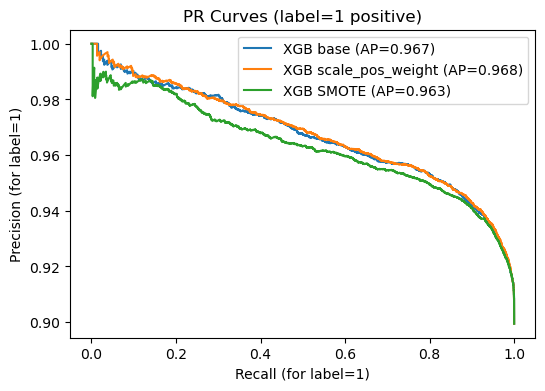

In [43]:
import matplotlib.pyplot as plt

def plot_pr_curves(y_true, proba_dict):
    plt.figure(figsize=(6,4))
    for name, y_prob in proba_dict.items():
        # positive=1 
        prec, rec, _ = precision_recall_curve(y_true, y_prob)
        ap = average_precision_score(y_true, y_prob)
        plt.plot(rec, prec, label=f'{name} (AP={ap:.3f})')
    plt.xlabel('Recall (for label=1)')
    plt.ylabel('Precision (for label=1)')
    plt.title('PR Curves (label=1 positive)')
    plt.legend()
    plt.show()

plot_pr_curves(y_test, {
    'XGB base': proba_xgb_base,
    'XGB scale_pos_weight': proba_xgb_w,
    'XGB SMOTE': proba_xgb_smote
})


In [44]:
df_results = pd.DataFrame(results)
# sort by non-churn(0) performance
df_results.sort_values(['F1(0)', 'Recall(0)', 'PR AUC'], ascending=False).reset_index(drop=True)


,model,AUC,PR AUC,Precision(0),Recall(0),F1(0),Precision(1),Recall(1),F1(1)
0,XGB(SMOTE) @thr(F1 for label0)=0.547,0.7808,0.9631,0.4143,0.4428,0.4281,0.9372,0.9300,0.9336
1,XGB (SMOTETomek),0.7837,0.9635,0.4430,0.4139,0.4279,0.9349,0.9418,0.9384
2,XGB (SMOTE),0.7808,0.9631,0.4449,0.4056,0.4244,0.9342,0.9434,0.9388
3,XGB (scale_pos_weight),0.7991,0.9676,0.2680,0.6384,0.3775,0.9522,0.8050,0.8724
4,XGB (baseline),0.7969,0.9671,0.7102,0.2333,0.3512,0.9203,0.9894,0.9536
5,RF (SMOTETomek),0.7352,0.9507,0.3797,0.3249,0.3502,0.9257,0.9406,0.9331
6,RF (SMOTE),0.7335,0.9505,0.3845,0.3202,0.3494,0.9254,0.9427,0.9339
7,RF (class_weight),0.7413,0.9527,0.3720,0.3270,0.3480,0.9257,0.9383,0.9320
8,RF (baseline),0.7393,0.9510,0.4339,0.2902,0.3478,0.9235,0.9577,0.9403
9,LogReg (class_weight),0.7639,0.9602,0.2054,0.7046,0.3181,0.9546,0.6952,0.8045


### A. Handling Class Imbalance - Conclusion
- Due to extreme class imbalance, we saw that baseline models predicted most customers as churn = 1, leading to very poor performance for churn = 0 (repeat buyers)
- Applying **Class Weighting, SMOTE(Oversampling), SMOTETomek(Oversampling + Undersampling)**, and **Threshold Tuning** slightly improved recall(0) but **did not meaningfully increase AUC or F1**.

This indicates that the traditional imbalance methods cannot address the underlying issue, **so we next adjusted the churn window to explore whether a more balanced definition improves performance.**

---

# (Extended) B. Adjusting Churn Window

`customer_orders["churned"] = customer_orders["days_since_last_order"] > `~~`90`~~` 150`

To further address class imbalance, the churn window was extended from 90 days to 150 days.

| 90 days | 150 days |
|:--:|:--:|
| <img src="images/churn.png" width="150"> | <img src="images/churn150.png" width="180"> |

As a result, the churn distribution shifted from roughly **90% churn / 10% non-churn** to **80% churn / 20% non-churn**, indicating a more balanced dataset.

---

| 90-day churn XGBoost | 150-day churn XGBoost |
|:--:|:--:|
| <img src="images/xgboost.png" width="250"> | <img src="images/xgboost150.png" width="200"> |

### B. Adjusting Churn Window - Conclusion

- When evaluated using the best-performing baseline model (**XGBoost**), extending the churn window from **90 days to 150 days** led to a **drop in AUC (0.80 -> 0.74)** and **weaker performance for churn = 0.**
- This declind suggests that the broader churn definition introduced additional noise and reduced the behavioral distinction between churned and active users.

These findings indicate that adjusting the churn window **did not lead to meaningful performance improvement**, highlighting the need to explore alternative modeling appraches beyond simple data redefinition.

<hr style="height:3px; border:none; background-color:black;">

# Overall conclusion 

- Across all experiments, **XGBoost consistently achieved the best baseline performance (AUC ≈ 0.80)**, but **extreme class imbalance** led to poor prediction for churn = 0 (repeat buyers).
- Attempts to address this issue through **(A) resampling methods** and **(B) churn window adjustment** provided only limited or even negative improvements.

Therefore, I decided to **reframe the problem** from binary classification to a **ranking / probability model**, focusing on estimating each customer’s likelihood of churn rather than predicting a hard label.


---

**Possible Future Work:**
- Feature Engineering: Incorporate **behavioral and sentiment-based features** (e.g., review text, complaint ratio) to enrich customer-level signals. \
(This part has been partially completed and will be integrated into the final model in later stages.)
- Model Interpretability: Use **Feature Importance and SHAP** to analyze key churn drivers and support business 
actionability.
- Model Extension: Experiment with **ranking-based objectives** (e.g., XGBoost rank:pairwise, LightGBM ranker) to optimize customer prioritization.
- Evaluation Refinement: Investigate **ranking metrics** (e.g., NDCG, Precision@k) for practical retention campaign targeting.